# Intergenerational Income Mobility Across U.S. Counties

This notebook investigates upward economic mobility at the county level in the United States. The goal is to use the the standard set of county-level predictors that Chetty et al. associate with mobility — segregation, school quality, family structure, income inequality, commute times, social capital, poverty, median household income, and population density — to explain *why* some counties produce more upward mobility than others, and whether a flexible machine-learning model uncovers structure that a linear model misses.

The outcome variable is `kfr_pooled_pooled_p25`: the mean adult income rank of children whose parents were at the 25th percentile of the national income distribution. This measure, along with most of the predictors, comes from the work of Raj Chetty and co-authors, who used IRS tax records linked to Census data to produce the first comprehensive county-level estimates of intergenerational mobility in the U.S. (Chetty, Hendren, Kline, Saez 2014; Chetty, Hendren, Jones, Porter 2020).

The notebook is organized into four parts:

1. **Data construction and feature engineering**: merge six county-level datasets on 5-digit FIPS code, build the 9-predictor analytic sample, and construct secondary outcomes for race and gender gap analysis.
2. **Exploratory analysis**: describe the distribution of mobility, urban-rural patterns, and the cross of segregation × poverty regimes.
3. **Econometric baseline (OLS)**: estimate a linear model on the 9 standardized predictors with HC3 robust standard errors, add four theory-motivated interaction terms, and re-estimate within urban-rural strata.
4. **Machine-learning comparison (Random Forest)**: fit a random forest on the same predictors, compare 5-fold cross-validated R² to OLS, and use SHAP values, SHAP interaction values, and partial dependence plots to interpret which interactions and non-linearities the linear model missed.

More than looking at *whether we can predict mobility well* (both models do reasonably well) we ask *what does the OLS-vs-RF gap reveal about the mechanisms behind mobility, and what would those mechanisms imply for policy?*

#### Imports and Settings

In [20]:
import warnings
warnings.filterwarnings("ignore")

Install `pyreadstat` (for reading the Stata `.dta` source files) and `shap` (used later for tree-model interpretation) into whichever Python the notebook kernel is running. Using `{sys.executable} -m pip` instead of bare `pip` guarantees the install lands in the same environment as the kernel, so the subsequent `import` cells can find both packages.

In [21]:
import sys
!{sys.executable} -m pip install pyreadstat shap -q

Import the numerical, plotting, and modeling libraries used throughout the notebook (pandas/numpy for data, matplotlib/seaborn for figures, pyreadstat for Stata files, scikit-learn and statsmodels for the OLS and random-forest pipelines, and SHAP for model interpretation). Centralizing imports here keeps later cells focused on analysis.

In [22]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pyreadstat
import shap
 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

Define the project color palette and matplotlib defaults. Done once so every figure in the notebook shares a consistent look (no top/right spines, dashed grid, DejaVu Sans), which keeps the eventual writeup visually coherent.

In [23]:
BLUE   = "#2C6E9B"
RED    = "#C0392B"
GREEN  = "#27AE60"
ORANGE = "#E67E22"
PURPLE = "#8E44AD"
GRAY   = "#7F8C8D"
BG     = "#F8F9FA"
 
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

Set the global random seed used throughout the notebook. A single `SEED` constant feeds every stochastic operation (random forest training, K-fold split shuffling, any later SHAP sampling) so that re-running the notebook yields identical numbers and figures. NumPy and Python's `random` are seeded as a defensive measure to catch any incidental randomness in helper libraries.

In [24]:
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

#### Data Construction and EDA

Seven county-level datasets merged on 5-digit FIPS code (`state * 1000 + county`).

| Dataset | File | Key variables pulled |
|---|---|---|
| Opportunity Atlas (2018) | `county_outcomes_dta.dta` | `kfr_pooled_pooled_p25`, race × sex mobility at p25:  **primary outcome** |
| Geography of Mobility (2014) | `onlinedata3.dta` | `gini`, `inc_share_1perc`, `s_rank_8082` |
| Changing Opportunity (2022) | `cty_covariates.dta` | `mean_commutetime2000`, `singleparent_share2010`, `poor_share2010`, `med_hhinc2016`, `popdensity2010` |
| Race & Economic Opportunity (2020) | `Table_8_county_covariates.dta` | `gini2010`, `singlepar_pooled2010`, `poor_share_black2010` (used only for the seg×pov regime stratifier, not as a predictor) |
| Health Inequality Project (Chetty Table 12) | `health_ineq_online_table_12.dta` | `cs_race_theil_2000` (racial segregation, Theil index), `cs00_seg_inc` (income segregation, Theil index), `score_r` (income-adjusted test-score percentile), `ccd_pup_tch_ratio` (pupil-teacher ratio) |
| Social Capital I (2022) | `social_capital_county.csv` | `ec_county` (economic connectedness) |
| NCHS Urban-Rural (2013) | `NCHSurb-rural-codes.csv` | `CODE2013` (6-level urban-rural class) |

Note on the segregation construct: earlier drafts used `poor_share_black2010` (Black poverty rate, with fallback to overall poverty share) as a "racial-economic concentration" segregation proxy. Diagnostic checks showed this variable is essentially uncorrelated (r ≈ 0.05) with proper Theil-index segregation measures and is more accurately described as a Black poverty rate. This draft therefore drops it and uses **two** Theil-index measures from the Health Inequality Project Table 12 instead: `cs_race_theil_2000` for racial segregation and `cs00_seg_inc` for income segregation. Both have zero missingness in the source file.

Note on the school-quality measure: earlier drafts used `gsmn_math_g3_2013` (raw 3rd-grade math scores from `cty_covariates.dta`) as the school-quality proxy. This draft replaces it with `score_r` from the Health Inequality Project's Table 12, which is income-adjusted and so closer to a school value-added measure than a level-of-affluence measure. The merge key in `health_ineq_online_table_12.dta` is `cty` (5-digit county FIPS), and the file is latin-1 encoded, so it must be loaded with `pyreadstat.read_dta(..., encoding="latin1")`.

**Step 0 — Data-loading imports.** `pandas` handles CSVs and the merged dataframe; `pyreadstat` is needed because Chetty's source files are Stata `.dta` files, which pandas cannot read natively. We import them once here so the per-source steps below stay focused on the data.

In [25]:
import pyreadstat
import pandas as pd

**Step 1 — Geography of Mobility (Chetty et al. 2014, `onlinedata3 (2).dta`).** This is the file underlying *Where is the Land of Opportunity?*, the paper that first established the county-level inequality, segregation, and Gini measures we use. The file's county identifier is called `county_id`; we rename it to `fips` to match the 5-digit FIPS convention used by every other source, and cast to `int` so the merge doesn't fail on float vs. int type mismatches.

In [26]:
df14, _ = pyreadstat.read_dta("data/onlinedata3 (2).dta")
df14 = df14.rename(columns={"county_id": "fips"})
df14["fips"] = df14["fips"].astype(int)

**Step 2 — Changing Opportunity covariates (Chetty et al. 2022, `cty_covariates.dta`).** This is the most recent county covariate release from Opportunity Insights and is the source for our commute-time, single-parent share, poverty, median-household-income, and population-density predictors. Unlike the Geography-of-Mobility file, it ships `state` and `county` as two separate integer columns rather than a single combined ID, so we construct the 5-digit FIPS code ourselves: `state * 1000 + county`.

In [27]:
cov, _ = pyreadstat.read_dta("data/cty_covariates.dta")
cov["fips"] = cov["state"].astype(int) * 1000 + cov["county"].astype(int)

**Step 3 — Race & Economic Opportunity Table 8 (Chetty et al. 2020, `Table_8_county_covariates.dta`).** Source for the *2010-vintage* Gini (`gini2010`), single-parent share (`singlepar_pooled2010`), and the racial-economic-concentration proxy `poor_share_black2010`. We prefer these 2010-vintage measures over the older Geography-of-Mobility ones when available, with the older versions kept as a fallback (handled later in feature engineering). Same `state * 1000 + county` FIPS construction as Step 2.

In [28]:
t8, _ = pyreadstat.read_dta("data/Table_8_county_covariates.dta")
t8["fips"] = t8["state"].astype(int) * 1000 + t8["county"].astype(int)

**Step 4 — Opportunity Atlas county outcomes (Chetty et al. 2018, `county_outcomes_dta.dta`).** This is the dataset that produces our **outcome variable** `kfr_pooled_pooled_p25` (the mean adult income rank of children whose parents were at the 25th national percentile), plus the race × sex breakdowns (`kfr_white_male_p25`, `kfr_black_male_p25`, etc.) used to construct the secondary racial- and gender-gap outcomes. The full file is enormous (thousands of estimates per county), so we restrict to a handful of mobility columns via the `usecols` argument — this keeps the notebook fast and the merged dataframe small.

In [29]:
key_cols = ["state", "county", "cz", "czname",
            "kfr_black_male_p25",   "kfr_black_female_p25",
            "kfr_white_male_p25",   "kfr_white_female_p25",
            "kfr_hisp_male_p25",    "kfr_hisp_female_p25",
            "kfr_pooled_male_p25",  "kfr_pooled_female_p25",
            "kfr_pooled_pooled_p25"]
df_out, _ = pyreadstat.read_dta("data/county_outcomes_dta.dta", usecols=key_cols)
df_out["fips"] = df_out["state"].astype(int) * 1000 + df_out["county"].astype(int)

**Step 5 — Social Capital (Chetty et al. 2022, `social_capital_county.csv`).** Source for the `ec_county` measure (*economic connectedness*, defined as the share of high-SES friends among low-SES residents) which is the social-capital predictor in the model. The file is a CSV (not Stata); its county identifier column is just called `county` and is already a 5-digit FIPS, so we only need to rename it to match our `fips` convention. We also keep four other social-capital metrics that are useful for diagnostic plots, even though only `ec_county` enters the regression.

In [30]:
sc = pd.read_csv("data/social_capital_county.csv")
sc = sc.rename(columns={"county": "fips"})
sc["fips"] = sc["fips"].astype(int)
sc = sc[["fips", "ec_county", "clustering_county",
         "support_ratio_county", "volunteering_rate_county",
         "civic_organizations_county"]]

**Step 6 — NCHS Urban-Rural classification (`NCHSurb-rural-codes.csv`).** The CDC's National Center for Health Statistics groups every U.S. county into one of six urban-rural categories (1 = Large Central Metro through 6 = Noncore Rural). We use this in two places later: as the stratifying variable in the urban-rural-stratified OLS (Figure 4), and as a coloring variable in EDA scatterplots. The file has a few special characters in the county-name column, so we read it with `encoding="latin1"` to avoid a `UnicodeDecodeError`. FIPS is constructed from the separate state and county columns (`STFIPS` and `CTYFIPS`), and the human-readable label is attached via a dictionary map.

In [31]:
nchs = pd.read_csv("data/NCHSurb-rural-codes.csv", encoding="latin1")
nchs["fips"] = nchs["STFIPS"] * 1000 + nchs["CTYFIPS"]
nchs_ur = nchs[["fips", "CODE2013"]].rename(columns={"CODE2013": "urban_rural_code"})
nchs_ur["urban_rural_label"] = nchs_ur["urban_rural_code"].map({
    1: "Large Central Metro", 2: "Large Fringe Metro",
    3: "Medium Metro",        4: "Small Metro",
    5: "Micropolitan",        6: "Noncore Rural"
})

**Step 7 — Health Inequality Project Table 12 (Chetty et al., `health_ineq_online_table_12.dta`).** This file is the source of the four variables in the new specification: `cs_race_theil_2000` (Theil-index racial segregation, used for `seg_race`), `cs00_seg_inc` (Theil-index income segregation, used for `seg_income`), `score_r` (income-adjusted test-score percentile, used for `school_quality`), and `ccd_pup_tch_ratio` (pupil-to-teacher ratio, used for `student_teacher_ratio`). Two gotchas worth knowing: (a) the file is **latin-1 encoded**, so the default UTF-8 read will crash with a `UnicodeDecodeError` — pass `encoding="latin1"`; (b) the FIPS column is called `cty` (not `fips`, not `county_id`, not `state`/`county` pair), so we rename it to match the convention used by every other source. We then keep only the four columns we need.

In [32]:
hi, _ = pyreadstat.read_dta("data/health_ineq_online_table_12.dta", encoding="latin1")
hi = hi.rename(columns={"cty": "fips"})
hi["fips"] = hi["fips"].astype(int)
hi = hi[["fips", "ccd_pup_tch_ratio", "score_r", "cs00_seg_inc", "cs_race_theil_2000"]]

**Step 8 — Merge all seven sources into a single county-level dataframe.** We start from `df_out` (the Opportunity Atlas outcomes file) and **left-join** every other source onto it on the shared `fips` key. Left-joining from `df_out` means we keep exactly the set of counties that have an outcome — counties present in a covariate file but not in the outcome file are silently dropped, which is what we want. From each source we pull only the columns needed downstream (the `[["fips", ...]]` subsetting inside each `.merge()`), so the final dataframe is wide enough to do feature engineering on but not polluted with hundreds of unused columns. The resulting `df.head(10)` lets you sanity-check the merge succeeded — every row should have a `fips`, an outcome, and the predictor columns.

In [33]:
df = (df_out
      .merge(df14[["fips", "s_rank_8082", "e_rank_b", "gini", "inc_share_1perc",
                   "p75_less_p25_within", "frac_kteenbirthfem"]], on="fips", how="left")
      .merge(cov[["fips", "mean_commutetime2000",
                  "singleparent_share2010", "poor_share2010", "med_hhinc2016",
                  "traveltime15_2010", "ann_avg_job_growth_2004_2013",
                  "popdensity2010"]], on="fips", how="left")
      .merge(t8[["fips", "gini2010", "singlepar_pooled2010",
                 "share_black2010", "poor_share_black2010"]], on="fips", how="left")
      .merge(sc, on="fips", how="left")
      .merge(nchs_ur, on="fips", how="left")
      .merge(hi, on="fips", how="left")
)

df.head(10)

,state,county,cz,czname,kfr_black_female_p25,kfr_hisp_female_p25,kfr_pooled_female_p25,kfr_white_female_p25,kfr_black_male_p25,kfr_hisp_male_p25,...,clustering_county,support_ratio_county,volunteering_rate_county,civic_organizations_county,urban_rural_code,urban_rural_label,ccd_pup_tch_ratio,score_r,cs00_seg_inc,cs_race_theil_2000
0,1.0,1.0,11101.0,Montgomery,0.316532,0.444835,0.373302,0.416631,0.297059,0.412351,...,0.10347,0.98275,0.04355,0.01518,3.0,Medium Metro,19.715980,-7.308133,0.036455,0.128216
1,1.0,3.0,11001.0,Mobile,0.305977,0.461809,0.399215,0.435208,0.298181,0.429707,...,0.09624,0.98684,0.06117,0.01526,4.0,Small Metro,16.850983,-13.628747,0.032571,0.100549
2,1.0,5.0,10301.0,Eufaula,0.311012,NaN,0.356089,0.439702,0.306210,NaN,...,0.14911,0.99911,0.02093,0.01474,6.0,Noncore Rural,16.656711,-15.955111,0.021680,0.039993
3,1.0,7.0,10801.0,Tuscaloosa,0.307754,NaN,0.355845,0.386489,0.311230,NaN,...,0.14252,0.99716,0.05294,0.01439,2.0,Large Fringe Metro,18.958192,-14.839100,0.017462,0.103550
4,1.0,9.0,10700.0,Birmingham,0.325251,0.435408,0.401055,0.415529,0.267119,0.473139,...,0.11243,0.99069,0.05704,0.01724,2.0,Large Fringe Metro,19.323810,-10.218139,0.013379,0.079703
5,1.0,11.0,9800.0,Auburn,0.329223,NaN,0.349057,0.501848,0.324206,NaN,...,0.18581,1.00000,0.01713,0.00975,6.0,Noncore Rural,19.717598,-18.839746,0.021242,0.047157
6,1.0,13.0,11101.0,Montgomery,0.311344,NaN,0.357346,0.417858,0.309114,NaN,...,0.16094,1.00000,0.03807,0.01286,6.0,Noncore Rural,17.337242,-25.707706,0.023980,0.092676
7,1.0,15.0,9600.0,LaGrange,0.330084,0.377225,0.373840,0.408250,0.299533,0.419859,...,0.11236,0.99701,0.05313,0.01739,4.0,Small Metro,19.376473,-7.025562,0.053608,0.208091
8,1.0,17.0,9600.0,LaGrange,0.321685,NaN,0.348502,0.384330,0.313022,NaN,...,0.13574,0.99759,0.02566,0.01098,5.0,Micropolitan,16.519606,-23.009960,0.006901,0.082469
9,1.0,19.0,6600.0,Rome,0.305133,NaN,0.362285,0.387946,0.302280,NaN,...,0.12273,0.99697,0.04666,0.01796,6.0,Noncore Rural,17.782280,-11.426178,0.005631,0.014170


Print the shape of the merged dataframe to confirm row and column counts after the six-source merge. A quick sanity check before moving on to feature engineering.

In [34]:
df.shape

(3219, 42)

#### Note on vintage mixing across data sources

The merged `df` is *vintage-mixed*: the variables in it come from different time periods, ranging from Census 2000 to Facebook friendship data observed in 2022. This is the standard practice in the Chetty et al. literature, but it is an analytic choice worth flagging explicitly so the reader can judge whether it threatens the interpretation.

| Variable | Vintage |
|---|---|
| Outcome (`kfr_pooled_pooled_p25`) | Children born ~1978–1983, adult outcomes observed ~2014–2015 |
| `seg_race` (= `cs_race_theil_2000`) | **2000** (Census 2000) |
| `seg_income` (= `cs00_seg_inc`) | **2000** (Census 2000) |
| `school_quality` (= `score_r`) | ~2009–2013 |
| `student_teacher_ratio` (= `ccd_pup_tch_ratio`) | ~2009–2013 |
| `single_parent` (= `singlepar_pooled2010`) | 2010 |
| `inequality` (= `gini2010`) | 2010 |
| `commute` (= `mean_commutetime2000`) | **2000** (Census 2000) |
| `social_capital` (= `ec_county`) | **2022** (Facebook friendships) |
| Controls (`poor_share2010`, `med_hhinc2016`, `popdensity2010`) | 2010 / 2016 / 2010 |
| `urban_rural_code` (stratifier) | 2013 (NCHS) |

**The identifying assumption** is that county-level structural traits — segregation, inequality, family structure, school resources, social capital — are *highly persistent over decades*. A county that was racially segregated in 2000 is almost certainly still segregated in 2020; a county that was income-unequal in 2010 still is. Under this persistence assumption, a small temporal mismatch between predictor and outcome is treated as measurement noise rather than a confound, and the predictors measured during the kids' teenage years (2010 vintage) are interpreted as a reasonable proxy for the environment that shaped the kids' adult outcomes.

**A nice consequence of the segregation swap** is that the two segregation measures (`seg_race` and `seg_income`) now share the same vintage — both are Census-2000 Theil indices from the same source — so within-construct vintage mismatch is eliminated for the segregation construct.

**The two genuinely loose joins are worth being upfront about:**

1. *`social_capital` (2022) vs. the outcome (kids born ~1980).* The kids whose mobility we're explaining were shaped by their county's connectedness in the 1980s–90s, not by Facebook friendships measured in 2022. The implicit defense is again persistence — connected counties today were probably connected then — but this is the single biggest temporal stretch in the model.
2. *`commute` (2000) vs. `inequality`/`single_parent`/etc. (2010).* Most of the predictor block is 2010-vintage; commute time is a decade earlier. Counties that were long-commute in 2000 mostly still are, so this is a small mismatch in practice.

These caveats are not fatal — the literature (Chetty 2014, 2020, 2022) does the same — but they should be stated in the write-up so the reader knows the model rests on county-level *persistence* rather than tight temporal alignment.

#### Feature Engineering

Constructed variables used in all models:-

| Variable | Construction | Interpretation |
|---|---|---|
| `mobility` | = `kfr_pooled_pooled_p25` | Primary outcome: mean income rank of children with parents at p25 |
| `racial_gap_wb` | = `kfr_white_male_p25 − kfr_black_male_p25` | White−Black male opportunity gap |
| `gender_gap_black` | = `kfr_black_female_p25 − kfr_black_male_p25` | Gender gap within Black community |
| `seg_race` | = `cs_race_theil_2000` (Chetty Health Inequality Table 12) | Racial segregation, Theil index, Census 2000 — replaces the prior `seg_score` (Black poverty rate), which was found to be essentially uncorrelated with proper segregation measures |
| `seg_income` | = `cs00_seg_inc` (Chetty Health Inequality Table 12) | Income segregation, Theil index, Census 2000 — captures how much income groups cluster spatially within a county |
| `inequality` | = `gini2010`, fallback to `gini` | Income inequality |
| `single_parent` | = `singlepar_pooled2010`, fallback to `singleparent_share2010` | Share of single-parent households |
| `school_quality` | = `score_r` (Chetty Health Inequality Table 12) | Test-score percentile, income-adjusted — closer to school value-added than raw scores. Replaces the previous raw 3rd-grade math score (`gsmn_math_g3_2013`). |
| `student_teacher_ratio` | = `ccd_pup_tch_ratio` (Chetty Health Inequality Table 12) | Pupil-to-teacher ratio — a school *input* measure, complementary to `school_quality` (an output measure) |
| `commute` | = `mean_commutetime2000` | Average commute time, 2000 |
| `social_capital` | = `ec_county` | Economic connectedness |
| `seg_hi` | = `cs_race_theil_2000 > median` | Binary: high-racial-segregation county (regime stratifier) |
| `pov_hi` | = `poor_share2010 > median` | Binary: high-poverty county |
| `regime_label` | 2×2 cross of `seg_hi` × `pov_hi` | Segregation-poverty regime for subgroup analysis |

In [35]:
df["mobility"]       = df["kfr_pooled_pooled_p25"]
df["racial_gap_wb"]  = df["kfr_white_male_p25"] - df["kfr_black_male_p25"]
df["gender_gap_black"] = df["kfr_black_female_p25"] - df["kfr_black_male_p25"]

df["seg_race"]              = df["cs_race_theil_2000"]
df["seg_income"]            = df["cs00_seg_inc"]
df["inequality"]            = df["gini2010"].fillna(df["gini"])
df["single_parent"]         = df["singlepar_pooled2010"].fillna(df["singleparent_share2010"])
df["school_quality"]        = df["score_r"]
df["student_teacher_ratio"] = df["ccd_pup_tch_ratio"]
df["commute"]               = df["mean_commutetime2000"]
df["social_capital"]        = df["ec_county"]

df["seg_hi"]  = df["seg_race"] > df["seg_race"].median()
df["pov_hi"]  = df["poor_share2010"] > df["poor_share2010"].median()
df["regime_label"] = (df["seg_hi"].astype(str) + "_seg_" +
                      df["pov_hi"].astype(str) + "_pov").map({
    "True_seg_True_pov":   "High Seg / High Pov",
    "True_seg_False_pov":  "High Seg / Low Pov",
    "False_seg_True_pov":  "Low Seg / High Pov",
    "False_seg_False_pov": "Low Seg / Low Pov",
})

cols_to_show = ["mobility", "racial_gap_wb", "gender_gap_black",
                "seg_race", "seg_income", "inequality", "single_parent",
                "school_quality", "student_teacher_ratio",
                "commute", "social_capital", "regime_label"]

df["ur_code"] = df["urban_rural_code"]

df[cols_to_show].head(10)

,mobility,racial_gap_wb,gender_gap_black,seg_race,seg_income,inequality,single_parent,school_quality,student_teacher_ratio,commute,social_capital,regime_label
0,0.361666,0.100258,0.019473,0.128216,0.036455,0.405,0.276716,-7.308133,19.715980,28.490602,0.72077,High Seg / Low Pov
1,0.388847,0.120363,0.007796,0.100549,0.032571,0.439,0.288834,-13.628747,16.850983,26.501080,0.74313,High Seg / Low Pov
2,0.349386,0.123980,0.004802,0.039993,0.021680,0.464,0.473958,-15.955111,16.656711,24.047514,0.41366,Low Seg / High Pov
3,0.363391,0.098941,-0.003476,0.103550,0.017462,0.411,0.317542,-14.839100,18.958192,32.875317,0.63152,High Seg / Low Pov
4,0.391879,0.125811,0.058132,0.079703,0.013379,0.422,0.224192,-10.218139,19.323810,36.189240,0.72562,High Seg / Low Pov
5,0.345659,0.161720,0.005018,0.047157,0.021242,0.533,0.600787,-18.839746,19.717598,26.251190,0.35515,Low Seg / High Pov
6,0.357249,0.123074,0.002229,0.092676,0.023980,0.463,0.448842,-25.707706,17.337242,26.863214,0.46026,High Seg / High Pov
7,0.361847,0.092772,0.030550,0.208091,0.053608,0.453,0.374189,-7.025562,19.376473,24.250038,0.60189,High Seg / High Pov
8,0.340575,0.063582,0.008664,0.082469,0.006901,0.425,0.455874,-23.009960,16.519606,23.371609,0.49761,High Seg / High Pov
9,0.365422,0.082614,0.002854,0.014170,0.005631,0.439,0.291386,-11.426178,17.782280,30.194675,0.60461,Low Seg / High Pov


**Variable classification by analytic role**

The variables constructed above fall into four roles in the analysis. The construction details are in the table just above; this table groups them by what they *do* in the modeling pipeline.

**Outcome (Y): Intergenerational mobility**

| Variable | Definition | Used for |
|---|---|---|
| `mobility` (= `kfr_pooled_pooled_p25`) | Mean adult income rank of children whose parents were at the 25th national percentile, county level (Opportunity Atlas) | Primary outcome in OLS and random forest |
| `racial_gap_wb` (= `kfr_white_male_p25 − kfr_black_male_p25`) | White-Black male p25 mobility gap | Secondary outcome for racial-gap heterogeneity |
| `gender_gap_black` (= `kfr_black_female_p25 − kfr_black_male_p25`) | Within-Black gender gap at p25 | Secondary outcome for gender-gap heterogeneity |

**Main predictors (X): the Chetty-style framework, with paired measures for segregation and school quality**

The framework now uses **two segregation measures** (racial and income, both Theil indices) and **two school-quality measures** (an output measure and an input measure), so each broad construct is captured by a complementary pair rather than a single proxy.

| Category | Variable | Definition |
|---|---|---|
| Segregation (racial) | `seg_race` | Theil-index racial segregation, Census 2000 (`cs_race_theil_2000`, Chetty Health Inequality Table 12). Higher values indicate more spatial sorting of racial groups within the county. |
| Segregation (income) | `seg_income` | Theil-index income segregation, Census 2000 (`cs00_seg_inc`, Chetty Health Inequality Table 12) — how much income groups cluster spatially, independent of race |
| School quality (output) | `school_quality` | Test-score percentile, income-adjusted (`score_r`, Chetty Health Inequality Table 12) — closer to school value-added than the raw 3rd-grade math score used previously |
| School quality (input) | `student_teacher_ratio` | Pupil-to-teacher ratio (`ccd_pup_tch_ratio`, Chetty Health Inequality Table 12) — captures school resources rather than student outcomes |
| Family structure | `single_parent` | Share of households with a single parent (`singlepar_pooled2010`, fallback `singleparent_share2010`) |
| Income inequality | `inequality` | County Gini coefficient (`gini2010`, fallback `gini`) |
| Social capital | `social_capital` | Economic connectedness — share of high-SES friends among low-SES residents (`ec_county`, Chetty et al. 2022) |
| Commuting / spatial frictions | `commute` | Mean one-way commute time, 2000 Census (`mean_commutetime2000`) |

**Controls (also included in X)**

| Variable | Definition |
|---|---|
| `poor_share2010` | Overall county poverty rate, 2010 — absorbs general economic distress not captured by the segregation measures |
| `med_hhinc2016` | Median household income, 2016 — absorbs the average level of resources |
| `popdensity2010` | Population density per square mile, 2010 — absorbs scale and urbanicity not captured by the urban-rural code |

**Stratification variables (used for subgroup analyses, not as predictors)**

| Variable | Definition |
|---|---|
| `urban_rural_code` / `urban_rural_label` | NCHS 6-level urban-rural classification (Large Central Metro through Noncore Rural) — used in the urban-rural-stratified OLS |
| `seg_hi` | Indicator for above-median `seg_race` (racial segregation) |
| `pov_hi` | Indicator for above-median `poor_share2010` |
| `regime_label` | 2x2 cross of `seg_hi` x `pov_hi` (e.g., "High Seg / High Pov") — used in the regime-comparison panels of Figure 2 |


Define the locked-in 11-predictor set (with `seg_race` + `seg_income` for the segregation construct and `school_quality` + `student_teacher_ratio` for the school-quality construct) and build the analytic sample by complete-case dropping rows missing the outcome or any predictor. We also report the resulting sample size since dropped rows are a substantive modeling decision.

In [36]:
PREDICTORS = ["seg_race", "seg_income",
              "school_quality", "student_teacher_ratio",
              "single_parent", "inequality", "commute", "social_capital",
              "poor_share2010", "med_hhinc2016", "popdensity2010"]

analytic = df[["fips", "czname", "urban_rural_label", "ur_code",
               "regime_label", "mobility", "racial_gap_wb", "gender_gap_black",
               "kfr_black_male_p25", "kfr_white_male_p25",
               "kfr_black_female_p25", "kfr_white_female_p25"] + PREDICTORS].dropna()

print(f"Analytic sample: {len(analytic)} counties (dropped {len(df)-len(analytic)} for missing)")

analytic[["mobility"] + PREDICTORS].head(10)

Analytic sample: 1382 counties (dropped 1837 for missing)


,mobility,seg_race,seg_income,school_quality,student_teacher_ratio,single_parent,inequality,commute,social_capital,poor_share2010,med_hhinc2016,popdensity2010
0,0.361666,0.128216,0.036455,-7.308133,19.715980,0.276716,0.405,28.490602,0.72077,0.105918,54052.804457,91.802681
1,0.388847,0.100549,0.032571,-13.628747,16.850983,0.288834,0.439,26.501080,0.74313,0.122942,52003.093474,114.647507
2,0.349386,0.039993,0.021680,-15.955111,16.656711,0.473958,0.464,24.047514,0.41366,0.250631,33114.854828,31.029207
3,0.363391,0.103550,0.017462,-14.839100,18.958192,0.317542,0.411,32.875317,0.63152,0.126850,39846.446520,36.806339
4,0.391879,0.079703,0.013379,-10.218139,19.323810,0.224192,0.422,36.189240,0.72562,0.133138,46361.122396,88.902191
5,0.345659,0.047157,0.021242,-18.839746,19.717598,0.600787,0.533,26.251190,0.35515,0.280449,31304.783397,17.523945
6,0.357249,0.092676,0.023980,-25.707706,17.337242,0.448842,0.463,26.863214,0.46026,0.255558,34026.987254,26.964750
7,0.361847,0.208091,0.053608,-7.025562,19.376473,0.374189,0.453,24.250038,0.60189,0.200562,42474.473064,200.312195
8,0.340575,0.082469,0.006901,-23.009960,16.519606,0.455874,0.425,23.371609,0.49761,0.203779,35054.860061,57.356522
9,0.365422,0.014170,0.005631,-11.426178,17.782280,0.291386,0.439,30.194675,0.60461,0.172289,38793.719997,46.936970


#### Initial EDA

_Figure 1: Distribution of Mobility and Urban-Rural Patterns_

Three panels:
1. Distribution of upward mobility across all 1,578 counties
2. Mobility by NCHS urban-rural class (large central metro → noncore rural)
3. Overall mobility vs. White−Black male gap, colored by urban-rural class

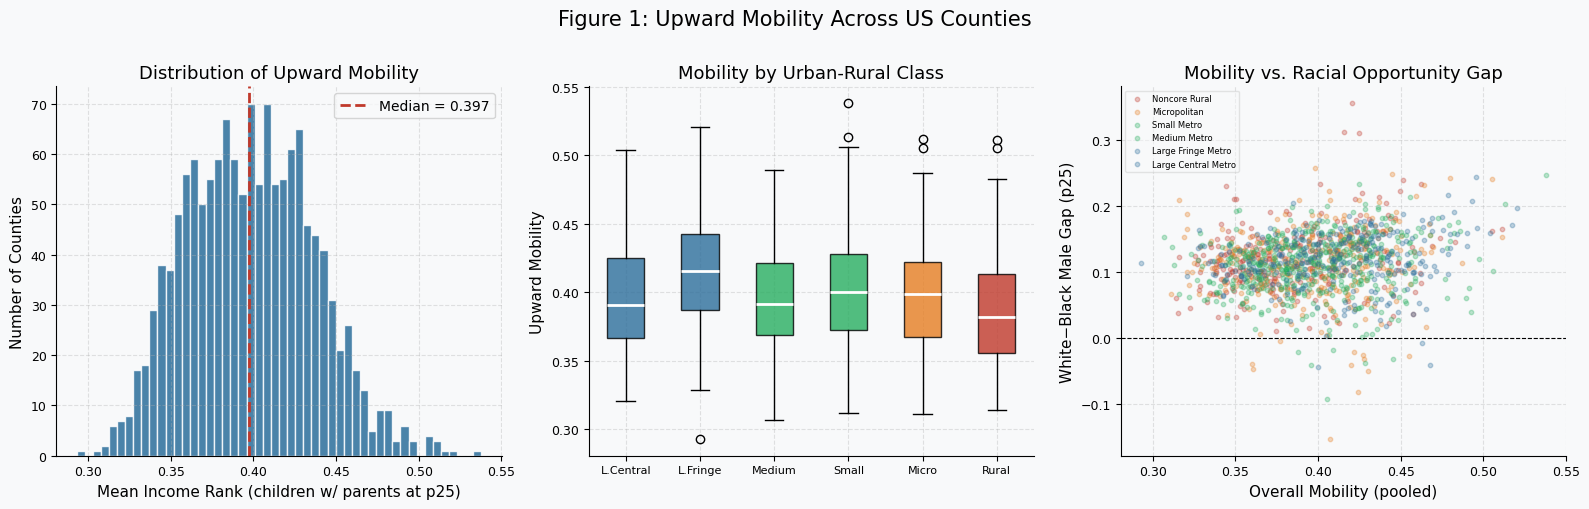

In [37]:
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure 1: Upward Mobility Across US Counties", fontsize=15, y=1.01)

# Panel 1: histogram
ax = axes[0]
ax.hist(analytic["mobility"], bins=50, color=BLUE, edgecolor="white", alpha=0.85)
ax.axvline(analytic["mobility"].median(), color=RED, lw=2, ls="--",
           label=f'Median = {analytic["mobility"].median():.3f}')
ax.set_xlabel("Mean Income Rank (children w/ parents at p25)")
ax.set_ylabel("Number of Counties")
ax.set_title("Distribution of Upward Mobility")
ax.legend()

# Panel 2: boxplot by urban-rural class
ax = axes[1]
ur_order = ["Large Central Metro", "Large Fringe Metro", "Medium Metro",
              "Small Metro", "Micropolitan", "Noncore Rural"]
colors_ur = [BLUE, BLUE, GREEN, GREEN, ORANGE, RED]
data_ur = [analytic.loc[analytic["urban_rural_label"] == u, "mobility"].dropna()
              for u in ur_order]
bp = ax.boxplot(data_ur, patch_artist=True, notch=False,
                medianprops=dict(color="white", lw=2))
for patch, c in zip(bp["boxes"], colors_ur):
    patch.set_facecolor(c); patch.set_alpha(0.8)
ax.set_xticks(range(1, 7))
ax.set_xticklabels(["L.Central", "L.Fringe", "Medium", "Small", "Micro", "Rural"],
                   fontsize=8)
ax.set_ylabel("Upward Mobility")
ax.set_title("Mobility by Urban-Rural Class")

# Panel 3: mobility vs racial gap
ax = axes[2]
for ur, color in zip(ur_order[::-1], [RED, ORANGE, GREEN, GREEN, BLUE, BLUE]):
    sub = analytic[analytic["urban_rural_label"] == ur]
    ax.scatter(sub["mobility"], sub["racial_gap_wb"],
               alpha=0.3, s=10, color=color, label=ur)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Overall Mobility (pooled)")
ax.set_ylabel("White−Black Male Gap (p25)")
ax.set_title("Mobility vs. Racial Opportunity Gap")
ax.legend(fontsize=6, loc="upper left", framealpha=0.5)

plt.tight_layout()

_Figure 2: Correlations and Segregation × Poverty Regimes_

Three panels:
1. Correlation heatmap of outcome and the main 11 predictors
2. Mobility distribution across the 4 segregation × poverty regimes
3. Race × sex mobility (Black/White men/women) within each regime

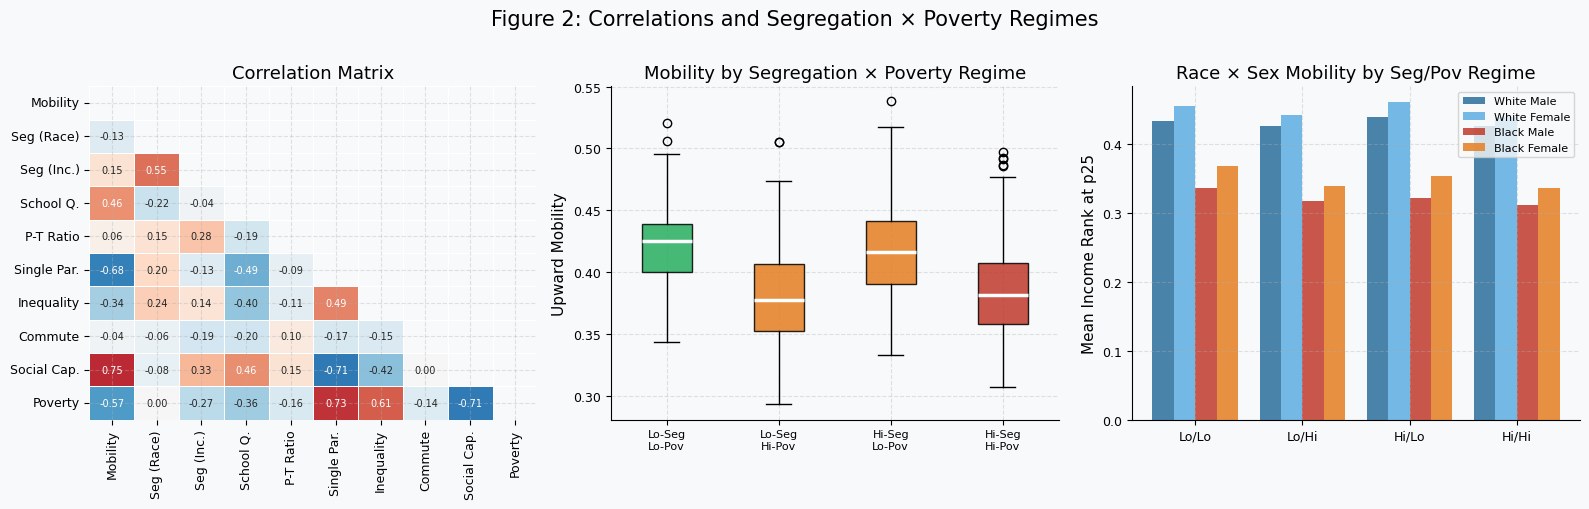

In [38]:
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure 2: Correlations and Segregation × Poverty Regimes", fontsize=15, y=1.01)

# Panel 1: correlation heatmap
ax = axes[0]
corr_cols = ["mobility", "seg_race", "seg_income",
             "school_quality", "student_teacher_ratio",
             "single_parent", "inequality", "commute",
             "social_capital", "poor_share2010"]
corr_labels = ["Mobility", "Seg (Race)", "Seg (Inc.)",
               "School Q.", "P-T Ratio",
               "Single Par.", "Inequality", "Commute",
               "Social Cap.", "Poverty"]
corr_mat = analytic[corr_cols].corr()
corr_mat.index = corr_labels
corr_mat.columns = corr_labels
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, ax=ax, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot_kws={"size": 7}, linewidths=0.4, cbar=False)
ax.set_title("Correlation Matrix")

# Panel 2: mobility by regime
ax = axes[1]
regime_order = ["Low Seg / Low Pov", "Low Seg / High Pov",
                 "High Seg / Low Pov", "High Seg / High Pov"]
regime_colors = [GREEN, ORANGE, ORANGE, RED]
data_reg = [analytic.loc[analytic["regime_label"] == r, "mobility"].dropna()
            for r in regime_order]
bp2 = ax.boxplot(data_reg, patch_artist=True,
                 medianprops=dict(color="white", lw=2.5))
for patch, c in zip(bp2["boxes"], regime_colors):
    patch.set_facecolor(c); patch.set_alpha(0.85)
ax.set_xticks(range(1, 5))
ax.set_xticklabels(["Lo-Seg\nLo-Pov", "Lo-Seg\nHi-Pov",
                    "Hi-Seg\nLo-Pov", "Hi-Seg\nHi-Pov"], fontsize=8)
ax.set_ylabel("Upward Mobility")
ax.set_title("Mobility by Segregation × Poverty Regime")

# Panel 3: race x sex mobility by regime
ax = axes[2]
race_sex = {
    "White Male":   ("kfr_white_male_p25",  BLUE),
    "White Female": ("kfr_white_female_p25", "#5DADE2"),
    "Black Male":   ("kfr_black_male_p25",   RED),
    "Black Female": ("kfr_black_female_p25", ORANGE),
}
x = np.arange(4)
width = 0.2
for i, (label, (col, color)) in enumerate(race_sex.items()):
    means = [analytic.loc[analytic["regime_label"] == r, col].mean()
             for r in regime_order]
    ax.bar(x + i * width, means, width, label=label, color=color, alpha=0.85)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(["Lo/Lo", "Lo/Hi", "Hi/Lo", "Hi/Hi"], fontsize=9)
ax.set_ylabel("Mean Income Rank at p25")
ax.set_title("Race × Sex Mobility by Seg/Pov Regime")
ax.legend(fontsize=8)

plt.tight_layout()

### OLS Model


**(1) Baseline OLS and OLS with theory-motivated interactions.**

The baseline regression estimates an additive linear model of mobility on the 11 standardized predictors with HC3 heteroskedasticity-robust standard errors:

$$\text{mobility}_c \;=\; \alpha + \boldsymbol{\beta}'\mathbf{X}_c + \varepsilon_c$$

where $c$ indexes counties and $\mathbf{X}_c$ is the vector of 11 standardized predictors:

$$\mathbf{X}_c = \big[\text{seg\_race},\ \text{seg\_income},\ \text{school\_quality},\ \text{student\_teacher\_ratio},\ \text{single\_parent},\ \text{inequality},\ \text{commute},\ \text{social\_capital},\ \text{poor\_share},\ \text{med\_hhinc},\ \text{popdensity}\big]_c$$

The interaction model adds four theory-motivated cross-terms (Chetty-style: segregation interacted with school quality, family structure, and social capital, plus an inequality × family-structure cross):

$$\text{mobility}_c \;=\; \alpha + \boldsymbol{\beta}'\mathbf{X}_c \;+\; \gamma_1\,(\text{seg\_race}\times\text{school\_quality})_c \;+\; \gamma_2\,(\text{seg\_race}\times\text{single\_parent})_c \;+\; \gamma_3\,(\text{inequality}\times\text{single\_parent})_c \;+\; \gamma_4\,(\text{seg\_race}\times\text{social\_capital})_c \;+\; \varepsilon_c$$

The interactions use `seg_race` (the racial-segregation Theil index) as the segregation channel because the original Chetty 2014 framework's interaction theory was about racial segregation; `seg_income` enters only as a main effect. Coefficients are standardized (predictors scaled to mean 0, SD 1), so magnitudes are directly comparable across variables.

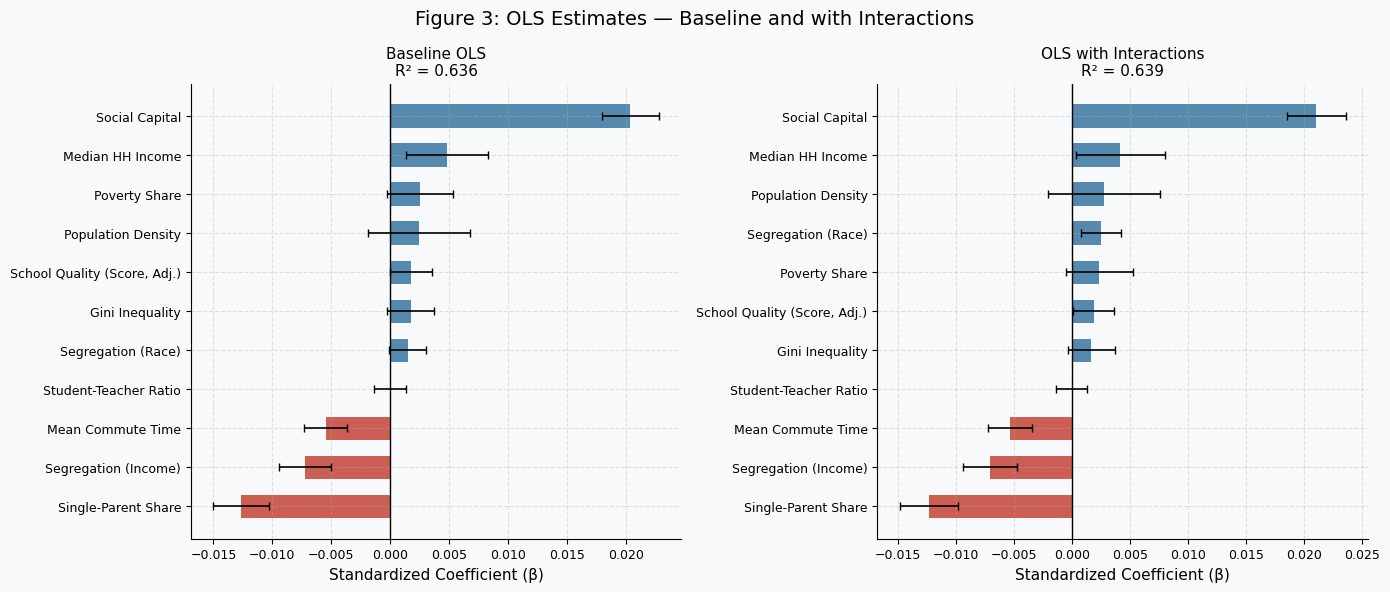

In [39]:
%matplotlib inline
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

# Standardize predictors
X_raw = analytic[PREDICTORS].copy()
scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_raw), columns=PREDICTORS, index=X_raw.index)
y = analytic["mobility"]

# Baseline OLS
X_ols = sm.add_constant(X_std)
ols_base = sm.OLS(y, X_ols).fit(cov_type="HC3")

# OLS with interactions — copy analytic and attach standardized columns
analytic_std = analytic.copy()
for col in PREDICTORS:
    analytic_std[col] = X_std[col].values

formula_interact = (
    "mobility ~ seg_race + seg_income + school_quality + student_teacher_ratio + "
    "single_parent + inequality + commute + social_capital + "
    "poor_share2010 + med_hhinc2016 + popdensity2010 + "
    "seg_race:school_quality + seg_race:single_parent + "
    "inequality:single_parent + seg_race:social_capital"
)
ols_interact = smf.ols(formula_interact, data=analytic_std).fit(cov_type="HC3")

pred_labels = {
    "seg_race":              "Segregation (Race)",
    "seg_income":            "Segregation (Income)",
    "school_quality":        "School Quality (Score, Adj.)",
    "student_teacher_ratio": "Student-Teacher Ratio",
    "single_parent":         "Single-Parent Share",
    "inequality":            "Gini Inequality",
    "commute":               "Mean Commute Time",
    "social_capital":        "Social Capital",
    "poor_share2010":        "Poverty Share",
    "med_hhinc2016":         "Median HH Income",
    "popdensity2010":        "Population Density",
}

def get_coef_data(model):
    params = model.params.drop("const", errors="ignore")
    cis = model.conf_int().drop("const", errors="ignore")
    params = params[params.index.isin(PREDICTORS)].sort_values()
    return params, cis.loc[params.index]

def draw_coef_bars(ax, params, cis):
    y_pos = np.arange(len(params))
    colors_ = [RED if v < 0 else BLUE for v in params.values]
    ax.barh(y_pos, params.values, color=colors_, alpha=0.8, height=0.6)
    ax.errorbar(params.values, y_pos,
                xerr=[params - cis[0], cis[1] - params],
                fmt="none", color="black", lw=1.2, capsize=3)
    ax.axvline(0, color="black", lw=1.0)
    return y_pos

def coef_plot(ax, model, title):
    params, cis = get_coef_data(model)
    y_pos = draw_coef_bars(ax, params, cis)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([pred_labels.get(v, v) for v in params.index], fontsize=9)
    ax.set_xlabel("Standardized Coefficient (β)")
    ax.set_title(f"{title}\nR² = {model.rsquared:.3f}", fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 3: OLS Estimates — Baseline and with Interactions", fontsize=14)
coef_plot(axes[0], ols_base,     "Baseline OLS")
coef_plot(axes[1], ols_interact, "OLS with Interactions")
plt.tight_layout()

Print the four interaction coefficients and their p-values from the interaction OLS. We isolate them here because the headline question is which interactions are detectable by a linear model, not the full coefficient table.

In [40]:
print(ols_interact.params[["seg_race:school_quality",
                            "seg_race:single_parent",
                            "inequality:single_parent",
                            "seg_race:social_capital"]])
print(ols_interact.pvalues[["seg_race:school_quality",
                             "seg_race:single_parent",
                             "inequality:single_parent",
                             "seg_race:social_capital"]])

seg_race:school_quality     0.000269
seg_race:single_parent     -0.002185
inequality:single_parent    0.000249
seg_race:social_capital    -0.000645
dtype: float64
seg_race:school_quality     0.763925
seg_race:single_parent      0.017267
inequality:single_parent    0.693983
seg_race:social_capital     0.528955
dtype: float64


^ With the new specification, the only interaction that crosses the conventional 5% threshold is `seg_race × single_parent` (β ≈ −0.002, p ≈ 0.017). The other three (seg_race × school_quality, inequality × single_parent, seg_race × social_capital) are statistically null. Adding all four interactions raises the R² by only ~0.003 over the baseline. This is consistent with the broader argument of the project: OLS struggles to surface interactions unless you already know exactly where to look. The random forest section that follows lets the data tell us which non-linear interactions actually matter.

**(2) OLS by NCHS urban-rural class — heterogeneity check.**

For each of the 6 NCHS urban-rural classes $g \in \{1,\dots,6\}$ (Large Central Metro through Noncore Rural), we re-estimate the baseline regression *within that class only*:

$$\text{mobility}_c \;=\; \alpha_g + \boldsymbol{\beta}_g'\mathbf{X}_c + \varepsilon_c \quad \text{for each } g$$

with predictors re-standardized within each class so the per-class coefficients are comparable in scale. The question is whether the same predictors matter equally everywhere, or whether the effect of school quality, segregation, or social capital varies systematically with urbanicity.

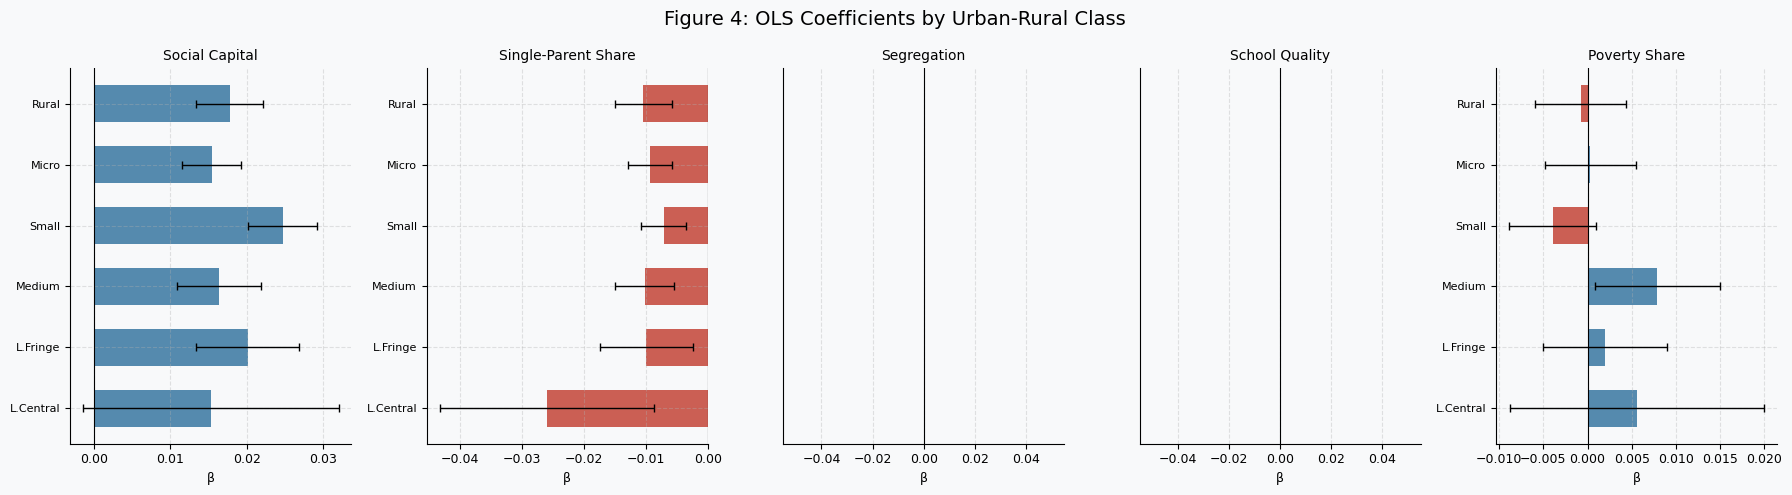

In [41]:
%matplotlib inline

ur_classes = ["Large Central Metro", "Large Fringe Metro", "Medium Metro",
              "Small Metro", "Micropolitan", "Noncore Rural"]
ur_short   = ["L.Central", "L.Fringe", "Medium", "Small", "Micro", "Rural"]

coef_records = []
for ur in ur_classes:
    sub = analytic_std[analytic_std["urban_rural_label"] == ur]
    if len(sub) < 30:
        continue
    X_sub = sm.add_constant(
        StandardScaler().fit_transform(sub[PREDICTORS])
    )
    X_sub = pd.DataFrame(X_sub, columns=["const"] + PREDICTORS)
    res   = sm.OLS(sub["mobility"].values, X_sub).fit(cov_type="HC3")
    for pred in PREDICTORS:
        coef_records.append({
            "ur":   ur,
            "pred": pred_labels.get(pred, pred),
            "coef": res.params[pred],
            "lo":   res.conf_int().loc[pred, 0],
            "hi":   res.conf_int().loc[pred, 1],
        })

coef_df = pd.DataFrame(coef_records)

top_preds = ["Social Capital", "Single-Parent Share", "Segregation",
             "School Quality", "Poverty Share"]
fig, axes = plt.subplots(1, len(top_preds), figsize=(18, 5), sharey=False)
fig.suptitle("Figure 4: OLS Coefficients by Urban-Rural Class", fontsize=14)

for ax, pred in zip(axes, top_preds):
    sub = coef_df[coef_df["pred"] == pred].copy()
    sub = sub[sub["ur"].isin(ur_classes)]
    sub["ur_short"] = sub["ur"].map(dict(zip(ur_classes, ur_short)))
    colors_ = [RED if v < 0 else BLUE for v in sub["coef"]]
    y_pos = np.arange(len(sub))
    ax.barh(y_pos, sub["coef"].values, color=colors_, alpha=0.8, height=0.6)
    ax.errorbar(sub["coef"].values, y_pos,
                xerr=[sub["coef"] - sub["lo"], sub["hi"] - sub["coef"]],
                fmt="none", color="black", lw=1.0, capsize=3)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub["ur_short"].values, fontsize=8)
    ax.set_title(pred, fontsize=10)
    ax.set_xlabel("β", fontsize=9)

plt.tight_layout()

#### OLS Summary Table

Coefficient table for baseline OLS and interaction OLS side by side, with standard errors and significance stars.

In [42]:
summary_rows = []
for pred in PREDICTORS:
    b0 = ols_base.params[pred]
    se0 = ols_base.bse[pred]
    p0 = ols_base.pvalues[pred]
    b1 = ols_interact.params.get(pred, float("nan"))
    se1 = ols_interact.bse.get(pred, float("nan"))
    p1 = ols_interact.pvalues.get(pred, float("nan"))

    def stars(p):
        if p < 0.01: return "***"
        if p < 0.05: return "**"
        if p < 0.10: return "*"
        return ""

    summary_rows.append({
        "Predictor":          pred_labels.get(pred, pred),
        "β (Baseline)":       f"{b0:.4f}{stars(p0)}",
        "SE (Baseline)":      f"({se0:.4f})",
        "β (Interactions)":   f"{b1:.4f}{stars(p1)}",
        "SE (Interactions)":  f"({se1:.4f})",
    })

results_df = pd.DataFrame(summary_rows)
print(f"Baseline OLS has R²: {ols_base.rsquared:.3f} | Adj R²: {ols_base.rsquared_adj:.3f} | N: {int(ols_base.nobs)}")
print(f"Interaction OLS has R²: {ols_interact.rsquared:.3f} | Adj R²: {ols_interact.rsquared_adj:.3f} | N: {int(ols_interact.nobs)}")
results_df

Baseline OLS has R²: 0.636 | Adj R²: 0.633 | N: 1382
Interaction OLS has R²: 0.639 | Adj R²: 0.636 | N: 1382


,Predictor,β (Baseline),SE (Baseline),β (Interactions),SE (Interactions)
0,Segregation (Race),0.0015*,(0.0008),0.0025***,(0.0009)
1,Segregation (Income),-0.0072***,(0.0011),-0.0070***,(0.0012)
2,"School Quality (Score, Adj.)",0.0018**,(0.0009),0.0019**,(0.0009)
3,Student-Teacher Ratio,0.0000,(0.0007),-0.0000,(0.0007)
4,Single-Parent Share,-0.0127***,(0.0012),-0.0123***,(0.0013)
5,Gini Inequality,0.0018*,(0.0010),0.0017,(0.0010)
6,Mean Commute Time,-0.0055***,(0.0009),-0.0053***,(0.0010)
7,Social Capital,0.0204***,(0.0012),0.0211***,(0.0013)
8,Poverty Share,0.0026*,(0.0014),0.0023,(0.0015)
9,Median HH Income,0.0048***,(0.0018),0.0042**,(0.0020)


**(3) Segregation specifications — does racial or income segregation drive the result?**

Because we now have two distinct segregation measures (`seg_race` and `seg_income`, both Theil indices from Census 2000), we re-estimate the baseline model under three nested specifications to see which segregation channel actually drives the relationship with mobility:

- **Specification A — racial segregation only** (drop `seg_income`):

$$\text{mobility}_c \;=\; \alpha + \beta_{\text{race}}\cdot\text{seg\_race}_c + \boldsymbol{\beta}'\mathbf{Z}_c + \varepsilon_c$$

- **Specification B — income segregation only** (drop `seg_race`):

$$\text{mobility}_c \;=\; \alpha + \beta_{\text{inc}}\cdot\text{seg\_income}_c + \boldsymbol{\beta}'\mathbf{Z}_c + \varepsilon_c$$

- **Specification C — both** (the headline baseline OLS from Step 1):

$$\text{mobility}_c \;=\; \alpha + \beta_{\text{race}}\cdot\text{seg\_race}_c + \beta_{\text{inc}}\cdot\text{seg\_income}_c + \boldsymbol{\beta}'\mathbf{Z}_c + \varepsilon_c$$

In each, $\mathbf{Z}_c$ is the vector of the 9 non-segregation predictors (school_quality, student_teacher_ratio, single_parent, inequality, commute, social_capital, poor_share, med_hhinc, popdensity), re-standardized for each fit. HC3 standard errors throughout. The table below reports the segregation coefficients, their p-values, and overall R² for each specification.

In [ ]:
NON_SEG = [p for p in PREDICTORS if not p.startswith("seg")]

def fit_spec(predictors):
    X = analytic[predictors].copy()
    X_std = pd.DataFrame(StandardScaler().fit_transform(X), columns=predictors, index=X.index)
    return sm.OLS(analytic["mobility"], sm.add_constant(X_std)).fit(cov_type="HC3")

spec_a = fit_spec(["seg_race"] + NON_SEG)
spec_b = fit_spec(["seg_income"] + NON_SEG)
spec_c = fit_spec(["seg_race", "seg_income"] + NON_SEG)

def fmt_beta(spec, name):
    if name not in spec.params: return "—"
    return f"{spec.params[name]:+.4f} (p={spec.pvalues[name]:.3f})"

def spec_row(spec, label):
    return {"Specification": label,
            "seg_race  β (p)":   fmt_beta(spec, "seg_race"),
            "seg_income β (p)":  fmt_beta(spec, "seg_income"),
            "R²": f"{spec.rsquared:.4f}",
            "N":  int(spec.nobs)}

seg_compare = pd.DataFrame([
    spec_row(spec_a, "(A) Race only"),
    spec_row(spec_b, "(B) Income only"),
    spec_row(spec_c, "(C) Both (current baseline)"),
])
seg_compare

**Interpretation — when both measures enter, the segregation story flips.**

Two findings in the comparison table are worth dwelling on:

1. **`seg_race` alone (Spec A) looks weakly negative; once `seg_income` is controlled for (Spec C), `seg_race` flips to *positive* (and remains marginal).** The race-only specification suggests racial segregation is mildly bad for mobility (β ≈ −0.001, p ≈ 0.09). But this is almost entirely driven by the fact that racially segregated counties also tend to be income-segregated (the two measures correlate at r ≈ 0.58). Once `seg_income` absorbs the income-sorting channel, `seg_race` switches sign — the small residual association is *positive*. A plausible reading: the racially-segregated-but-income-mixed counties left over after the residualization are disproportionately affluent suburban communities (e.g., predominantly-white wealthy suburbs), where mobility is high for structural reasons unrelated to race. This is a genuine omitted-variable story, not an artifact.

2. **`seg_income` is the dominant segregation channel.** It is strongly negative and highly significant in both Spec B (β ≈ −0.006, p < 0.001) and Spec C (β ≈ −0.007, p < 0.001), and its effect size *grows* once `seg_race` is added — consistent with `seg_race` partly suppressing the income-segregation effect when omitted. Substantively: a 1-SD increase in income segregation is associated with about a 0.7-percentile-rank decrease in adult income for kids who started at the 25th percentile.

**Why this matters for the policy interpretation.** The classical Chetty 2014 finding — *"segregation predicts lower mobility"* — is, in our specification, more precisely *"income segregation, not racial segregation, predicts lower mobility, and what looked like a racial-segregation effect was largely an income-sorting effect masquerading as one."* For policy: integration efforts that mix incomes (mixed-income housing, school-attendance-zone redrawing) appear to be doing more of the work than integration along racial lines per se. This is a non-trivial reframing of the Chetty story and is exactly the kind of distinction that requires having both segregation measures in the same model — which is *only* possible because we expanded the predictor set in this draft.

### Random Forest

Trains a Random Forest regressor on the same 11 standardized predictors and outcome.

**Hyperparameter choices** (fixed, not tuned). With only 1,382 counties an exhaustive grid search risks overfitting the CV folds themselves, so we pick defensible default values and use 5-fold CV purely to *score* the model rather than to select hyperparameters:

- `n_estimators=500` — large enough that variance from finite forest size is negligible relative to sampling variance.
- `max_features=0.33` — the standard regression-RF rule (~p/3, where p=11), which decorrelates trees at the cost of a small bias hit.
- `min_samples_leaf=5` — a mild regularizer that prevents pure-leaf overfitting on a county-N≈1,400 sample.

Reports OOB R² (a free held-out estimate from the bootstrap samples), 5-fold CV R² (more conservative, full retraining per fold), and the OLS baseline R² for comparison.

OLS R²: 0.636
RF OOB R²: 0.686
RF CV R²: 0.677


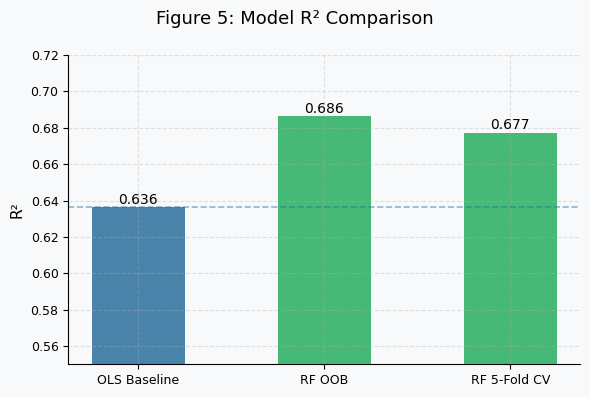

In [43]:
%matplotlib inline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score
import shap

X = X_std.values
y_vals = y.values

rf = RandomForestRegressor(
    n_estimators=500,
    max_features=0.33,
    min_samples_leaf=5,
    oob_score=True,
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X, y_vals)

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_r2 = cross_val_score(rf, X, y_vals, cv=cv, scoring="r2").mean()
oob_r2 = rf.oob_score_
ols_r2 = ols_base.rsquared

print(f"OLS R²: {ols_r2:.3f}")
print(f"RF OOB R²: {oob_r2:.3f}")
print(f"RF CV R²: {cv_r2:.3f}")

# Figure 5: model comparison bar
fig, ax = plt.subplots(figsize=(6, 4))
fig.suptitle("Figure 5: Model R² Comparison", fontsize=13)
labels = ["OLS Baseline", "RF OOB", "RF 5-Fold CV"]
vals = [ols_r2, oob_r2, cv_r2]
colors_ = [BLUE, GREEN, GREEN]
bars = ax.bar(labels, vals, color=colors_, alpha=0.85, width=0.5)
ax.set_ylim(0.55, 0.72)
ax.set_ylabel("R²")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
            f"{v:.3f}", ha="center", fontsize=10)
ax.axhline(ols_r2, color=BLUE, lw=1.2, ls="--", alpha=0.5)
plt.tight_layout()

(1) SHAP Values: Feature Importance and Directions

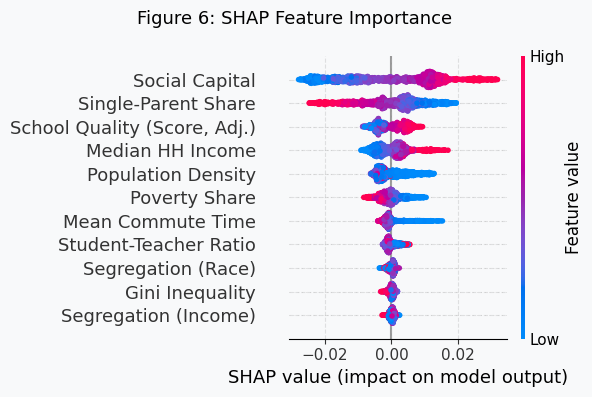

In [44]:
%matplotlib inline

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap_df = pd.DataFrame(shap_values, columns=PREDICTORS)

fig, ax = plt.subplots(figsize=(6, 4))
fig.suptitle("Figure 6: SHAP Feature Importance", fontsize=13)
shap.summary_plot(shap_values, X, feature_names=[pred_labels[p] for p in PREDICTORS],
                  show=False, plot_size=None)
plt.tight_layout()

(2) SHAP Interaction Effects: Mean absolute SHAP interaction values between the top feature pairs. Captures how much each pair of features jointly shifts predictions beyond their individual contributions.

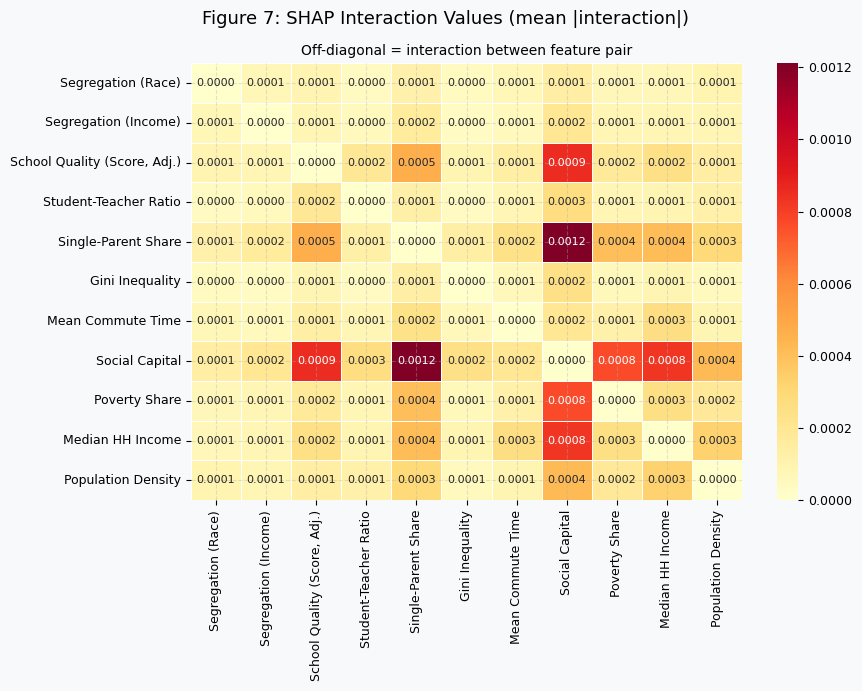

In [45]:
%matplotlib inline

shap_interact = explainer.shap_interaction_values(X)

# Mean absolute interaction matrix (off-diagonal = true interactions)
interact_mat = np.abs(shap_interact).mean(axis=0)
np.fill_diagonal(interact_mat, 0)

labels_short = [pred_labels[p] for p in PREDICTORS]
interact_df  = pd.DataFrame(interact_mat, index=labels_short, columns=labels_short)

fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle("Figure 7: SHAP Interaction Values (mean |interaction|)", fontsize=13)
sns.heatmap(interact_df, ax=ax, cmap="YlOrRd", annot=True, fmt=".4f",
            annot_kws={"size": 8}, linewidths=0.4)
ax.set_title("Off-diagonal = interaction between feature pair", fontsize=10)
plt.tight_layout()

(3) Partial Dependence Plots - Top Features: Shows the marginal effect of each top predictor on mobility, averaging over all other features. Reveals non-linearities the linear model cannot capture.

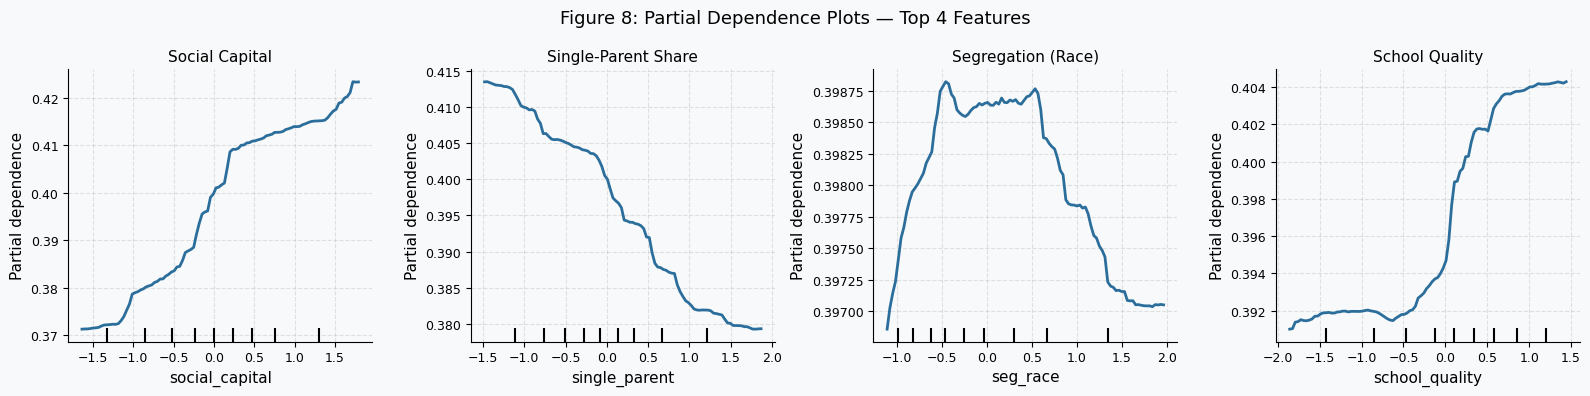

In [46]:
%matplotlib inline
from sklearn.inspection import PartialDependenceDisplay

top4_idx = [PREDICTORS.index(p) for p in
            ["social_capital", "single_parent", "seg_race", "school_quality"]]
top4_labels = ["Social Capital", "Single-Parent Share", "Segregation (Race)", "School Quality"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Figure 8: Partial Dependence Plots — Top 4 Features", fontsize=13)

for ax, idx, label in zip(axes, top4_idx, top4_labels):
    PartialDependenceDisplay.from_estimator(
        rf, X, [idx], ax=ax,
        feature_names=PREDICTORS,
        line_kw={"color": BLUE, "lw": 2}
    )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("")

plt.tight_layout()

### Final Results Table:

In [47]:
import pandas as pd
import numpy as np

# SHAP mean absolute values (overall importance)
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=PREDICTORS
)

# SHAP mean absolute interaction (row sum, excluding diagonal)
interact_importance = pd.Series(
    interact_mat.sum(axis=1),
    index=labels_short
).rename(index={v: k for k, v in pred_labels.items()})

# OLS significance stars
def stars(p):
    if p < 0.01:  return "***"
    if p < 0.05:  return "**"
    if p < 0.10:  return "*"
    return ""

rows = []
for pred in PREDICTORS:
    b   = ols_base.params[pred]
    p   = ols_base.pvalues[pred]
    rows.append({
        "Predictor":            pred_labels[pred],
        "OLS β":                f"{b:.4f}",
        "Sig.":                 stars(p),
        "OLS p-value":          f"{p:.3f}",
        "SHAP Importance":      f"{shap_importance[pred]:.4f}",
        "SHAP Interaction Sum": f"{interact_importance.get(pred, 0):.4f}",
    })

final_df = pd.DataFrame(rows).sort_values(
    "SHAP Importance", ascending=False
).reset_index(drop=True)

print(f"OLS R²: {ols_base.rsquared:.3f} | RF CV R²: {cv_r2:.3f} | "
      f"RF OOB R²: {oob_r2:.3f} | N = {len(analytic)}")
final_df

OLS R²: 0.636 | RF CV R²: 0.677 | RF OOB R²: 0.686 | N = 1382


,Predictor,OLS β,Sig.,OLS p-value,SHAP Importance,SHAP Interaction Sum
0,Social Capital,0.0204,***,0.000,0.0130,0.0051
1,Single-Parent Share,-0.0127,***,0.000,0.0074,0.0036
2,"School Quality (Score, Adj.)",0.0018,**,0.048,0.0038,0.0025
3,Median HH Income,0.0048,***,0.007,0.0036,0.0027
4,Population Density,0.0025,,0.267,0.0035,0.0018
5,Poverty Share,0.0026,*,0.072,0.0024,0.0022
6,Mean Commute Time,-0.0055,***,0.000,0.0020,0.0013
7,Student-Teacher Ratio,0.0000,,0.986,0.0013,0.0011
8,Segregation (Race),0.0015,*,0.060,0.0007,0.0008
9,Segregation (Income),-0.0072,***,0.000,0.0005,0.0009
